# GARALEN — Analysis Notebook

This notebook analyses the simulation output from a statistical perspective, working directly from the CSV generated by `src/generate_data.py`. Unlike `examination.ipynb`, which inspects model internals, this notebook treats the data as an observer would: without access to the underlying parameters.

The anomalous mission (`crisa`, shown in red) is compared against the 30 baseline missions (gray) across several detection strategies: raw loss series, per-episode variance and maxima, cross-mission percentile ranking, and scatter analysis.

**Prerequisite:** run `python src/generate_data.py` before opening this notebook to ensure `data/simulation.csv` exists.

## 1. Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load simulation data — run src/generate_data.py first if data/simulation.csv is missing
PROJECT_ROOT = Path().resolve().parent
df = pd.read_csv(PROJECT_ROOT / "data" / "simulation.csv")
print(df.shape)
print(df.mission_id.unique())

(28830, 5)
<StringArray>
[     'crisa', 'mission_01', 'mission_02', 'mission_03', 'mission_04',
 'mission_05', 'mission_06', 'mission_07', 'mission_08', 'mission_09',
 'mission_10', 'mission_11', 'mission_12', 'mission_13', 'mission_14',
 'mission_15', 'mission_16', 'mission_17', 'mission_18', 'mission_19',
 'mission_20', 'mission_21', 'mission_22', 'mission_23', 'mission_24',
 'mission_25', 'mission_26', 'mission_27', 'mission_28', 'mission_29',
 'mission_30']
Length: 31, dtype: str


## 2. Raw loss series

All 31 missions plotted over time. The baseline missions form a gray band; Crisa (red) should sit visibly below during the anomalous period. At this resolution the anomaly may be subtle — the following cells provide more sensitive detection methods.

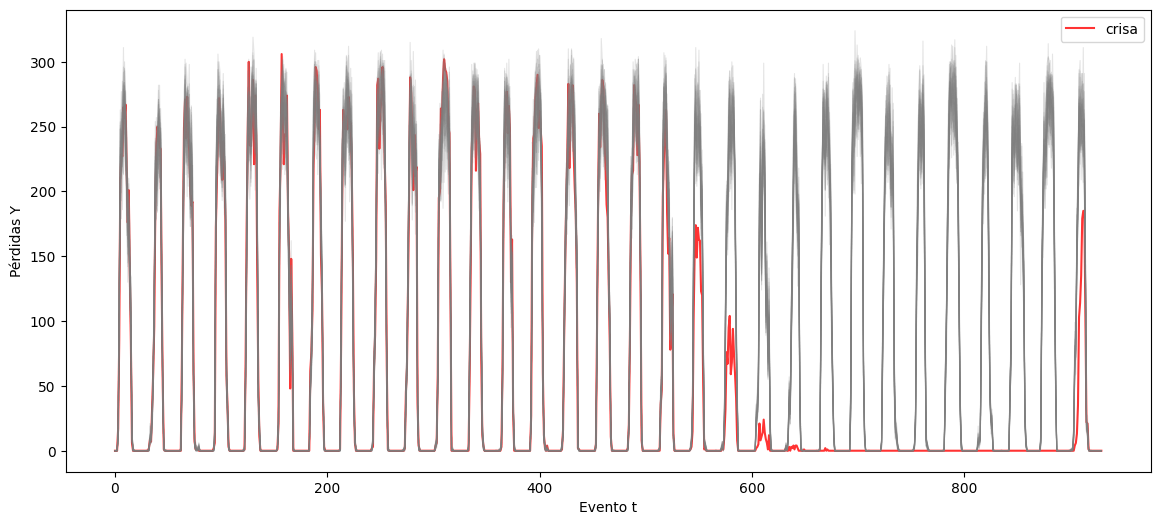

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

for mission in df.mission_id.unique():
    datos = df[df.mission_id == mission]
    if mission == "crisa":
        ax.plot(datos.t, datos.Y, color="red", alpha=0.8, linewidth=1.5, label="crisa")
    else:
        ax.plot(datos.t, datos.Y, color="gray", alpha=0.2, linewidth=0.8)

ax.set_xlabel("Evento t")
ax.set_ylabel("Pérdidas Y")
ax.legend()
plt.show()

## 3. Stress episode detection

The severity process produces recurring high-stress episodes. We identify them as contiguous segments where the cross-mission mean loss exceeds a threshold. These episodes are used in the following cells as the unit of comparison — the anomaly signal is stronger within episodes than across the full series.

In [3]:
Y_ref = df.groupby("t")["Y"].mean().values

umbral = 2
es_cero = Y_ref <= umbral

cruces = np.diff(es_cero.astype(int))
inicios = np.where(cruces == -1)[0] + 1
fines = np.where(cruces == 1)[0]

pares = [(ini, fin) for ini, fin in zip(inicios, fines) if fin > ini + 2]
print(f"Ventanas detectadas: {len(pares)}")

Ventanas detectadas: 31


## 4. Per-episode statistics

For each detected stress episode and each mission, we compute variance and maximum losses. This produces a results table used in the scatter and percentile plots below.

In [4]:
misiones = df.mission_id.unique()
resultados = []

for mission in misiones:
    Y = df[df.mission_id == mission]["Y"].values
    for ini, fin in pares:
        segmento = Y[ini:fin]
        if len(segmento) > 2:
            resultados.append({
                "mission_id": mission,
                "centro": (ini + fin) / 2,
                "varianza": segmento.var(),
                "maximo": segmento.max()
            })

res = pd.DataFrame(resultados)
ventanas = res.centro.unique()
print(res.head())
print(f"Ventanas: {len(pares)} | Misiones: {len(res.mission_id.unique())}")

  mission_id  centro     varianza  maximo
0      crisa     9.5  5774.899408   267.0
1      crisa    39.0  8866.243056   250.0
2      crisa    69.0  4638.388889   273.0
3      crisa   100.5  7237.976331   272.0
4      crisa   129.5  5878.994083   300.0
Ventanas: 31 | Misiones: 31


### 4.1 Variance and maxima per episode

Crisa's variance and peak losses per episode (red) overlaid on the baseline cloud (gray). Crisa should consistently appear at the lower end of the distribution during the anomalous period.

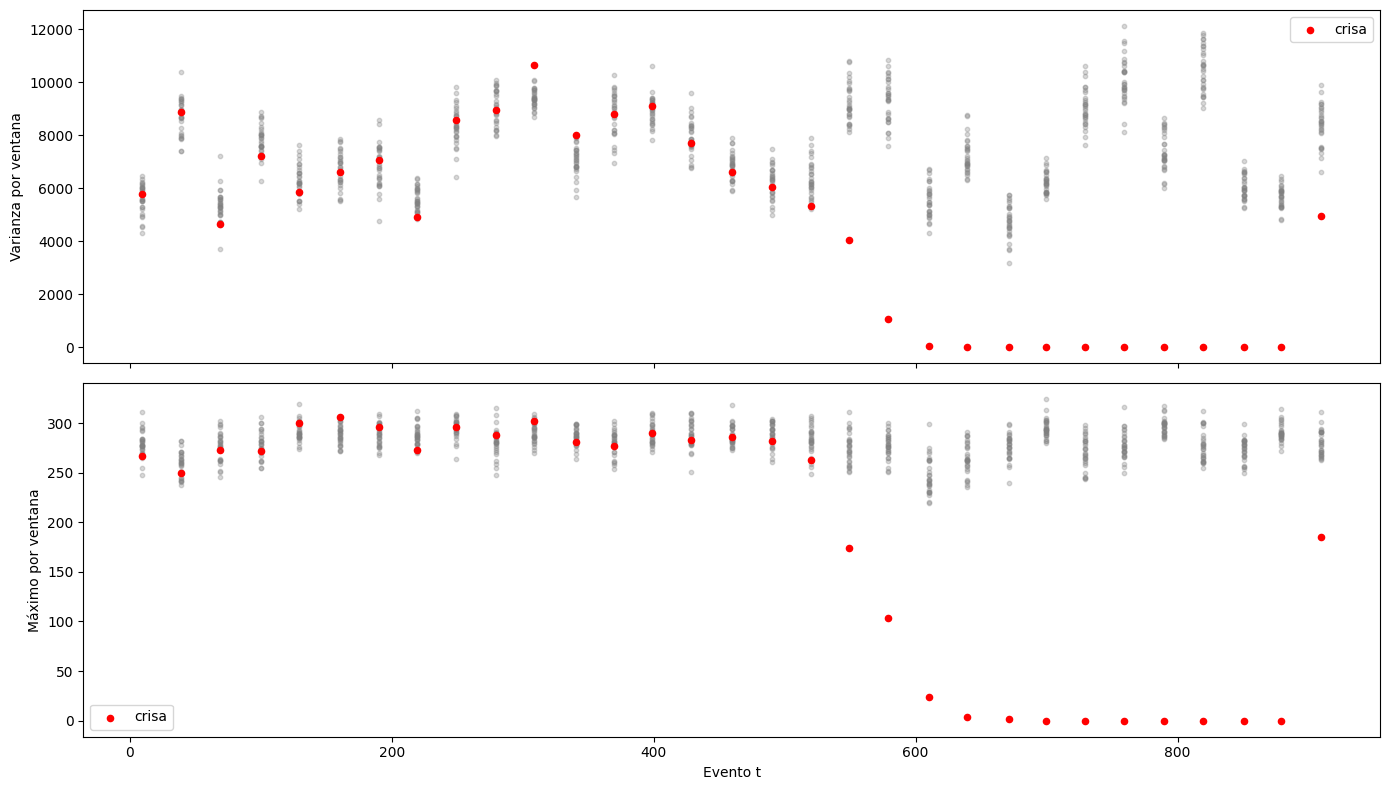

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for mission in misiones:
    datos = res[res.mission_id == mission]
    if mission == "crisa":
        axes[0].scatter(datos.centro, datos.varianza, color="red", s=20, zorder=5, label="crisa")
        axes[1].scatter(datos.centro, datos.maximo, color="red", s=20, zorder=5, label="crisa")
    else:
        axes[0].scatter(datos.centro, datos.varianza, color="gray", alpha=0.3, s=10)
        axes[1].scatter(datos.centro, datos.maximo, color="gray", alpha=0.3, s=10)

axes[0].set_ylabel("Varianza por ventana")
axes[1].set_ylabel("Máximo por ventana")
axes[1].set_xlabel("Evento t")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.2 Completeness check

Verify that every mission has an entry for every detected episode. Any missing combinations are printed — an empty output means the table is complete.

In [6]:
for v in ventanas:
    datos_v = res[res.centro == v]
    for mission in misiones:
        filas = datos_v[datos_v.mission_id == mission]
        if len(filas) == 0:
            print(f"Falta: mission={mission}, ventana={v}")

## 5. Cross-mission percentile ranking

For each episode, we compute Crisa's percentile rank among all missions in both variance and peak losses. A mission with no anomaly should rank around 0.5 on average. Crisa should consistently rank below 0.5 during the anomalous period — this is the most sensitive detection method in this notebook.

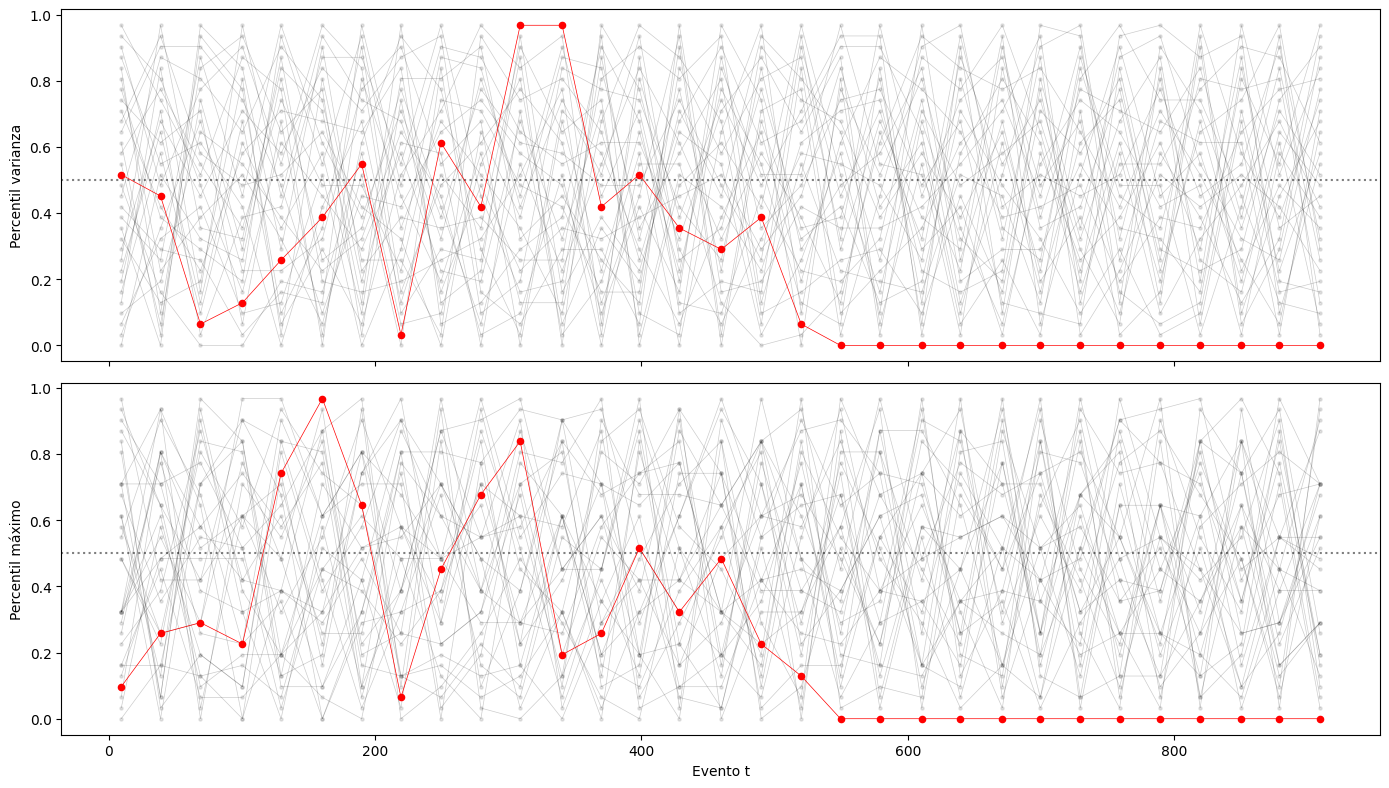

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for mission in misiones:
    perc_var = []
    perc_max = []
    for v in ventanas:
        datos_v = res[res.centro == v]
        val_var = datos_v[datos_v.mission_id == mission]["varianza"].values[0]
        val_max = datos_v[datos_v.mission_id == mission]["maximo"].values[0]
        perc_var.append((val_var > datos_v["varianza"]).mean())
        perc_max.append((val_max > datos_v["maximo"]).mean())

    if mission == "crisa":
        axes[0].plot(ventanas, perc_var, color="red", linewidth=0.5, zorder=5)
        axes[0].scatter(ventanas, perc_var, color="red", s=20, zorder=6)
        axes[1].plot(ventanas, perc_max, color="red", linewidth=0.5, zorder=5)
        axes[1].scatter(ventanas, perc_max, color="red", s=20, zorder=6)
    else:
        axes[0].plot(ventanas, perc_var, color="black", alpha=0.2, linewidth=0.5)
        axes[0].scatter(ventanas, perc_var, color="gray", alpha=0.2, s=5)
        axes[1].plot(ventanas, perc_max, color="black", alpha=0.2, linewidth=0.5)
        axes[1].scatter(ventanas, perc_max, color="gray", alpha=0.2, s=5)

axes[0].axhline(0.5, color="black", linestyle=":", alpha=0.5)
axes[1].axhline(0.5, color="black", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Percentil varianza")
axes[1].set_ylabel("Percentil máximo")
axes[1].set_xlabel("Evento t")
plt.tight_layout()
plt.show()

## 6. Scatter analysis

### 6.1 Linear scale

Losses vs. severity and losses vs. decision load for all missions, across the full time series. Two features are visible in Crisa's cloud: a higher concentration of zero or near-zero losses (consequence of the reduced failure probability), and some points above the baseline cloud at high severity (a result of mixing the anomalous and post-anomaly periods — once the influence dissipates, Crisa returns to baseline but the binomial variance at high N can push individual events above it). The scatter is not a sensitive anomaly detector; its value is showing the overall S → N → Y structure shared by all missions.

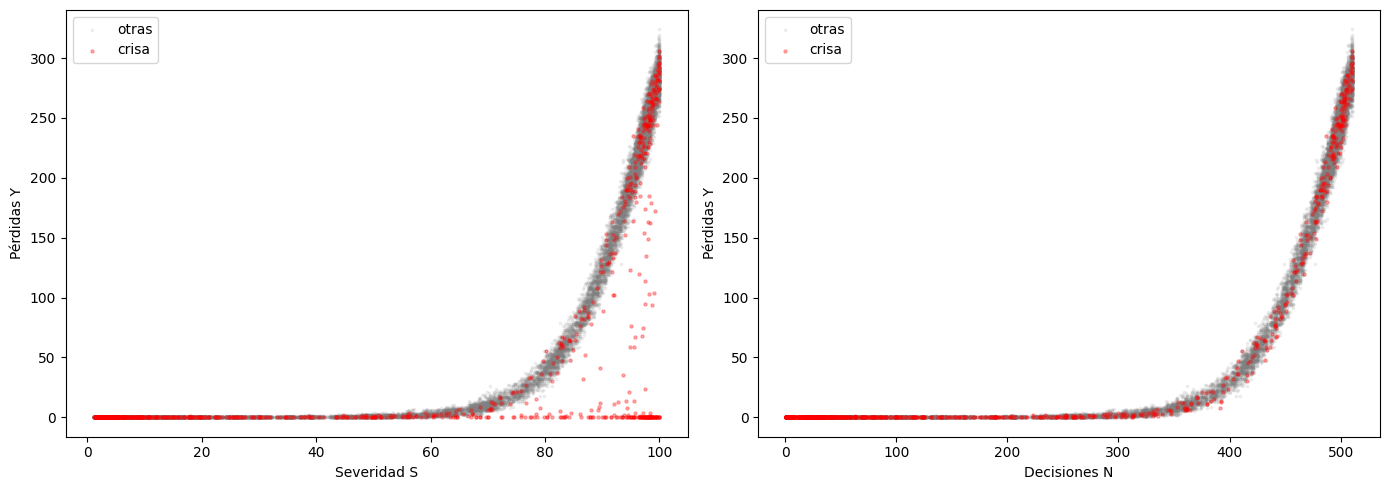

In [10]:
crisa = df[df.mission_id == "crisa"]
otras = df[df.mission_id != "crisa"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(otras.S, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[0].scatter(crisa.S, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[0].set_xlabel("Severidad S")
axes[0].set_ylabel("Pérdidas Y")
axes[0].legend()

axes[1].scatter(otras.N, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[1].scatter(crisa.N, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[1].set_xlabel("Decisiones N")
axes[1].set_ylabel("Pérdidas Y")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Log scale

Logarithmic axes separate the low-loss regime from the high-stress regime. The rightward shift of some of Crisa's points relative to the baseline cloud is the same temporal mixing effect seen in the linear plot: post-t_star events where the anomaly is no longer active but high-severity fluctuations remain large. On log scale the zero-loss concentration disappears (zeros are undefined on log axes), making the high-severity behavior more prominent.

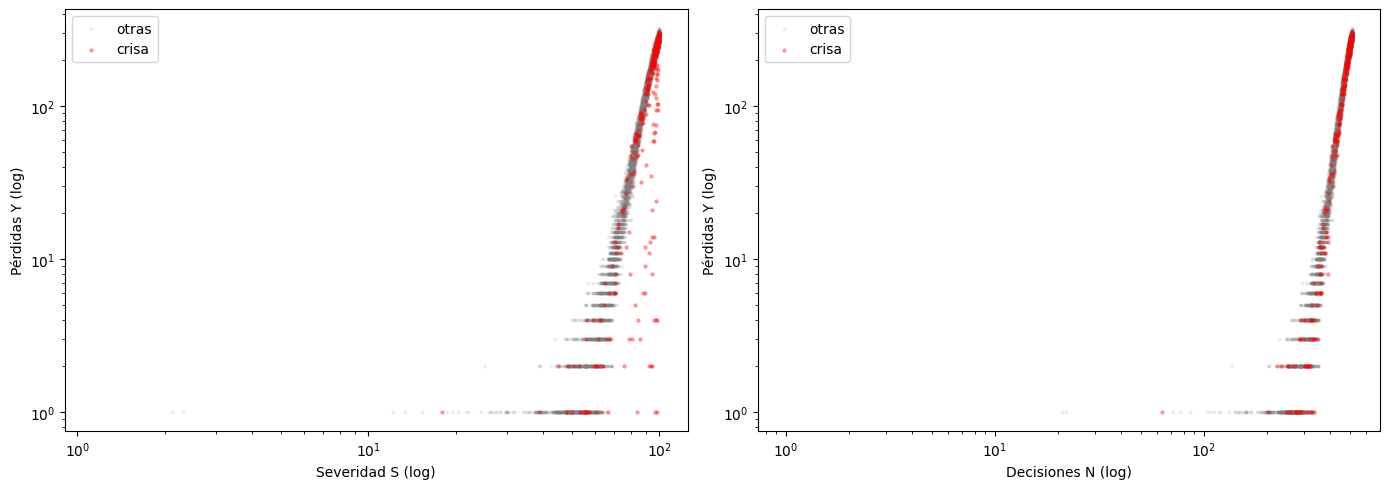

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(otras.S, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[0].scatter(crisa.S, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Severidad S (log)")
axes[0].set_ylabel("Pérdidas Y (log)")
axes[0].legend()

axes[1].scatter(otras.N, otras.Y, alpha=0.1, s=3, color="gray", label="otras")
axes[1].scatter(crisa.N, crisa.Y, alpha=0.3, s=5, color="red", label="crisa")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Decisiones N (log)")
axes[1].set_ylabel("Pérdidas Y (log)")
axes[1].legend()

plt.tight_layout()
plt.show()